## Submission 1. Counting SWR events around Change-of-mind time

In [ ]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pickle
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import ranksums
from spyglass.shijiegu.Analysis_SGU import RippleTimesWithDecode, TrialChoice

[2026-04-18 11:26:53,328][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [3]:
from spyglass.shijiegu.changeOfMind_remote import find_posterior_sum_segment, find_remote_theta_animal_new
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day, return_triggered_2d_position
from spyglass.shijiegu.changeOfMindRipple import triggered_ripple_animal
from spyglass.shijiegu.changeOfMind_figures.figure2_ripple import figure2_ripple_data, return_ripple_metrics

from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm

from spyglass.shijiegu.changeOfMind_remote_location import draw_maze, get_kde, plot_density

[11:27:34][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[11:27:34][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[11:27:34][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[11:27:34][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackG

### 1. tally

In [17]:
### Run this for data export to Dandi purpose only.
import os
import datajoint as dj

from spyglass.common.common_usage import Export, ExportSelection
paper_key = {"paper_id": "Gu2026"}

ExportSelection().start_export(**paper_key, analysis_id="ripple")

[20:18:12][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[20:18:12][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[20:18:12][INFO] Spyglass: Starting {'export_id': 109}
INFO:spyglass:Starting {'export_id': 109}


In [ ]:
list_of_days_animals = {}
success_animal = {}

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']

animal = 'lewis'
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']


for animal in ["molly","eliot","klein","lewis","julio"]:
    print("Processing animal:", animal)
    dates_to_plot = list_of_days_animals[animal]

    success_animal[animal] = figure2_ripple_data(
        animal, dates_to_plot,
        parameter_name = 'default_conservative',
        home_ripple = False)


[20:18:16][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


Processing animal: molly
currently investigating:
02_Seq2Session1
pos 1 valid times


[2026-04-27 20:18:17,170][WARNING]: Skipped checksum for file with hash: eb43f8d9-4c83-3e33-251a-3879cdd40562, and path: /stelmo/nwb/analysis/molly20220416/molly20220416_QF4WSNTPEI.nwb
[2026-04-27 20:18:17,184][WARNING]: Skipped checksum for file with hash: eb43f8d9-4c83-3e33-251a-3879cdd40562, and path: /stelmo/nwb/analysis/molly20220416/molly20220416_QF4WSNTPEI.nwb
[2026-04-27 20:18:17,231][WARNING]: Skipped checksum for file with hash: eb43f8d9-4c83-3e33-251a-3879cdd40562, and path: /stelmo/nwb/analysis/molly20220416/molly20220416_QF4WSNTPEI.nwb
[2026-04-27 20:18:17,240][WARNING]: Skipped checksum for file with hash: eb43f8d9-4c83-3e33-251a-3879cdd40562, and path: /stelmo/nwb/analysis/molly20220416/molly20220416_QF4WSNTPEI.nwb
[2026-04-27 20:18:28,062][WARNING]: Skipped checksum for file with hash: 53105d14-5a5d-73c8-9ef1-daceb3086d5b, and path: /stelmo/nwb/analysis/molly20220416_FY8O57UM5F.nwb
[2026-04-27 20:18:28,077][WARNING]: Skipped checksum for file with hash: 53105d14-5a5d-73

02_Seq2Session1 0
currently investigating:
04_Seq2Session2
pos 3 valid times


[2026-04-27 20:18:39,010][WARNING]: Skipped checksum for file with hash: dc5c4373-c6be-bdf0-147a-c41abdfab48c, and path: /stelmo/nwb/analysis/molly20220416/molly20220416_ZRS5WXGDIB.nwb
[2026-04-27 20:18:39,023][WARNING]: Skipped checksum for file with hash: dc5c4373-c6be-bdf0-147a-c41abdfab48c, and path: /stelmo/nwb/analysis/molly20220416/molly20220416_ZRS5WXGDIB.nwb
[2026-04-27 20:18:39,068][WARNING]: Skipped checksum for file with hash: dc5c4373-c6be-bdf0-147a-c41abdfab48c, and path: /stelmo/nwb/analysis/molly20220416/molly20220416_ZRS5WXGDIB.nwb
[2026-04-27 20:18:39,077][WARNING]: Skipped checksum for file with hash: dc5c4373-c6be-bdf0-147a-c41abdfab48c, and path: /stelmo/nwb/analysis/molly20220416/molly20220416_ZRS5WXGDIB.nwb
[2026-04-27 20:18:49,320][WARNING]: Skipped checksum for file with hash: d9c2d134-7752-a9ec-94fc-e7881f4c8616, and path: /stelmo/nwb/analysis/molly20220416_9C9N25HKFD.nwb
[2026-04-27 20:18:49,333][WARNING]: Skipped checksum for file with hash: d9c2d134-7752-a9

...

[2026-04-27 20:46:28,218][WARNING]: Skipped checksum for file with hash: 2f26491d-8e4d-3ba0-3240-0a718e8796fe, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_NYNU3U5EQF.nwb
[2026-04-27 20:46:28,232][WARNING]: Skipped checksum for file with hash: 2f26491d-8e4d-3ba0-3240-0a718e8796fe, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_NYNU3U5EQF.nwb
[2026-04-27 20:46:28,279][WARNING]: Skipped checksum for file with hash: 2f26491d-8e4d-3ba0-3240-0a718e8796fe, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_NYNU3U5EQF.nwb
[2026-04-27 20:46:28,288][WARNING]: Skipped checksum for file with hash: 2f26491d-8e4d-3ba0-3240-0a718e8796fe, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_NYNU3U5EQF.nwb
[2026-04-27 20:46:38,508][WARNING]: Skipped checksum for file with hash: 51e40c9a-e926-56c3-b943-3e2c6549ebac, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_T7K0C4K7VR.nwb
[2026-04-27 20:46:38,523][WARNING]: Skipped checksum for file with hash: 51

04_Rev2Session2 8
pre restrict time 16 1699126440.0224557
pre restrict time 27 1699126980.5801637
pre restrict time 37 1699127311.8079848
pre restrict time 41 1699127418.571927
pre restrict time 48 1699127632.5918117
pre restrict time 49 1699127681.0337853
pre restrict time 67 1699128286.5634584
currently investigating:
06_Rev2Session3
pos 5 valid times


[2026-04-27 20:46:49,843][WARNING]: Skipped checksum for file with hash: fcc5334b-cc62-6098-57b1-f25cbbe7496e, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_YJ7ZEJ5SH3.nwb
[2026-04-27 20:46:49,857][WARNING]: Skipped checksum for file with hash: fcc5334b-cc62-6098-57b1-f25cbbe7496e, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_YJ7ZEJ5SH3.nwb
[2026-04-27 20:46:49,903][WARNING]: Skipped checksum for file with hash: fcc5334b-cc62-6098-57b1-f25cbbe7496e, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_YJ7ZEJ5SH3.nwb
[2026-04-27 20:46:49,912][WARNING]: Skipped checksum for file with hash: fcc5334b-cc62-6098-57b1-f25cbbe7496e, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_YJ7ZEJ5SH3.nwb
[2026-04-27 20:46:59,912][WARNING]: Skipped checksum for file with hash: f9eee400-e83e-4099-ba83-df4eac704135, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_13HVLI1ROL.nwb
[2026-04-27 20:46:59,925][WARNING]: Skipped checksum for file with hash: f9

06_Rev2Session3 10
pre restrict time 22 1699131125.2766643
pre restrict time 23 1699131168.4246438
pre restrict time 28 1699131337.8345628
pre restrict time 37 1699131622.132427
pre restrict time 42 1699131842.5163217
pre restrict time 49 1699132067.3922143
pre restrict time 63 1699132562.2759778
pre restrict time 77 1699133096.2217228
currently investigating:
08_Rev2Session4
pos 7 valid times


[2026-04-27 20:47:11,203][WARNING]: Skipped checksum for file with hash: ed4e4974-f1d2-e417-14ec-00f1b00c34db, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_2IL7XN263I.nwb
[2026-04-27 20:47:11,217][WARNING]: Skipped checksum for file with hash: ed4e4974-f1d2-e417-14ec-00f1b00c34db, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_2IL7XN263I.nwb
[2026-04-27 20:47:11,263][WARNING]: Skipped checksum for file with hash: ed4e4974-f1d2-e417-14ec-00f1b00c34db, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_2IL7XN263I.nwb
[2026-04-27 20:47:11,271][WARNING]: Skipped checksum for file with hash: ed4e4974-f1d2-e417-14ec-00f1b00c34db, and path: /stelmo/nwb/analysis/klein20231104/klein20231104_2IL7XN263I.nwb


In [29]:
success_animal

{'molly': 1, 'eliot': 1, 'klein': 1, 'lewis': 1, 'julio': 1}

### 2. plotting

In [30]:
from matplotlib.colors import Normalize
import matplotlib as mpl
import starbars
from scipy import stats
cmap = mpl.colormaps['cool']

In [31]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure2'

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/molly_ripple.pickle
p_value 0.3113693506914837
p_value 0.255295480422448
p_value 0.3330895164562679
p_value 0.4197653934326061

 Rat M average of 0.37 SWR per CoM trial, 0.8 SWR per nonrewarded trial, 0.43 SWR per rewarded trial
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/eliot_ripple.pickle
p_value 0.7636481697542137
p_value 0.06655901099179012
p_value 0.0059560411289210306
p_value 0.1534849717330623

 Rat E average of 0.15 SWR per CoM trial, 0.32 SWR per nonrewarded trial, 0.44 SWR per rewarded trial
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/klein_ripple.pickle
p_value 0.7177596762630666
p_value 0.012541359458157602
p_value 0.45402758109851293
p_value 0.004422623584028665

 Rat K average of 0.02 SWR per CoM trial, 0.05 SWR per nonrewarded trial, 0.35 SWR per rewarded trial
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/

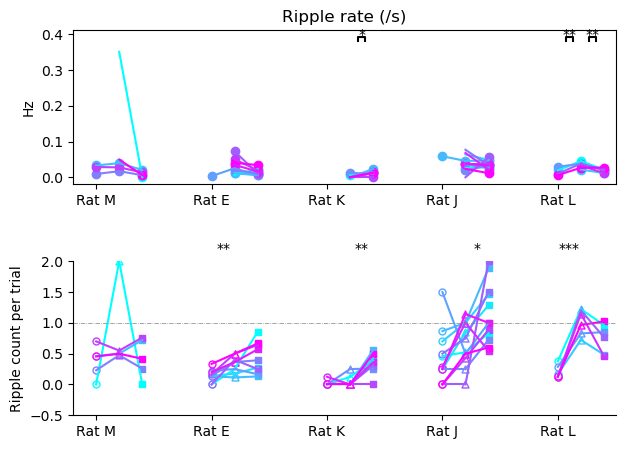

In [32]:
fig,axes = plt.subplots(2,1,figsize = (7,5))
plt.subplots_adjust(wspace=0.8, hspace=0.5)

animal_ind = 0
animals = ["molly","eliot",'klein',"julio","lewis",]#,"Klein","Lewis1","Julio"]
both_flag = True
home_ripple = False
version_main_text = False

annotations1, annotations2 = [], []

for animal in animals:

    if home_ripple:
        file_path = f"{output_folder}/{animal[:5]}_home_ripple.pickle"
    else:
        file_path = f"{output_folder}/{animal[:5]}_ripple.pickle"
    
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")

    dates_to_plot = list(data["ranges"].keys())
    

    norm = Normalize(vmin=0, vmax=len(dates_to_plot)-1)

    ratio1, ratio2, ratio3 = [], [], []
    count1, count2, count3 = [], [], []
    for d_ind in range(len(dates_to_plot)):
        d = dates_to_plot[d_ind]

        (ratio, ratio_nearby, ratio_nearby_rewarded,
             ripple_num, ripple_num_nearby, ripple_num_nearby_rewarded) = return_ripple_metrics(data, d, both_flag)

        
        ratio1.append(ratio)
        ratio2.append(ratio_nearby)
        ratio3.append(ratio_nearby_rewarded)

        count1.append(ripple_num)
        count2.append(ripple_num_nearby)
        count3.append(ripple_num_nearby_rewarded)

        axe = axes[0]
        if len(data["ranges"][d]) >= 5:
            axe.scatter(np.zeros_like(ratio) + animal_ind, ratio, color = cmap(norm(d_ind)))
        if len(data["ranges_nearby"][d]) >= 5:
            axe.scatter(np.zeros_like(ratio_nearby) + animal_ind + 0.2, ratio_nearby, color = cmap(norm(d_ind)))
        if len(data["ranges"][d]) >= 5 and len(data["ranges_nearby"][d]) >= 5:
            axe.plot(np.array([0,0.2]) + animal_ind,[ratio, ratio_nearby],color = cmap(norm(d_ind)))
        
        if not version_main_text:
            axe.scatter(np.zeros_like(ratio_nearby_rewarded) + animal_ind + 0.4, ratio_nearby_rewarded, color = cmap(norm(d_ind)))
            axe.plot(np.array([0.2,0.4]) + animal_ind,[ratio_nearby, ratio_nearby_rewarded],color = cmap(norm(d_ind)))

        axe = axes[1]
        dot_size = 25
        axe.scatter(np.zeros_like(ripple_num) + animal_ind, ripple_num,
                    edgecolor = cmap(norm(d_ind)), facecolor = 'white', s = dot_size, marker = "o")
        axe.scatter(np.zeros_like(ripple_num_nearby) + animal_ind + 0.2, ripple_num_nearby,
                    edgecolor = cmap(norm(d_ind)), facecolor = 'white', s = dot_size, marker = "^")
        axe.plot(np.array([0,0.2]) + animal_ind,[ripple_num, ripple_num_nearby],
                    color = cmap(norm(d_ind)))

        if not version_main_text:
            axe.scatter(np.zeros_like(ripple_num_nearby_rewarded) + animal_ind + 0.4, ripple_num_nearby_rewarded,
                        facecolor = cmap(norm(d_ind)), s = dot_size, marker = "s")
            axe.plot(np.array([0.2,0.4]) + animal_ind,[ripple_num_nearby, ripple_num_nearby_rewarded],color = cmap(norm(d_ind)))
        

    #### add stats
    t_statistic, p_value = stats.ttest_rel(ratio1, ratio2)
    print("p_value", p_value)
    if p_value < 0.05:
        annotations1.append((animal_ind, animal_ind + 0.2, np.round(p_value, 4)))

    if not version_main_text:
        t_statistic, p_value = stats.ttest_rel(ratio2, ratio3)
        print("p_value", p_value)
        if p_value < 0.05:
            annotations1.append((animal_ind + 0.2, animal_ind + 0.4, np.round(p_value, 4)))

    t_statistic, p_value = stats.ttest_rel(count1, count2)
    print("p_value", p_value)
    if p_value < 0.05:
        annotations2.append((animal_ind, animal_ind + 0.2, np.round(p_value, 4)))

    if not version_main_text:
        t_statistic, p_value = stats.ttest_rel(count2, count3)
        print("p_value", p_value)
        if p_value < 0.05:
            annotations2.append((animal_ind + 0.2, animal_ind + 0.4, np.round(p_value, 4)))
    ########
    print(f"\n Rat {animal[0].upper()} average of {np.round(np.mean(count1),2)} SWR per CoM trial, {np.round(np.mean(count2),2)} SWR per nonrewarded trial, {np.round(np.mean(count3),2)} SWR per rewarded trial")
    animal_ind += 1



axes[0].set_xticks(np.arange(len(animals)));
axes[0].set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
axes[0].set_xlim([-0.2,len(animals)-0.5]);
#axes[0].set_ylim([0,0.2])
if home_ripple:
    axes[0].set_title("Ripple rate at home well (/s)")
else:
    axes[0].set_title("Ripple rate (/s)")
axes[0].set_ylabel("Hz")

axes[1].set_xticks(np.arange(len(animals)));
axes[1].set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
axes[1].set_xlim([-0.2,len(animals)-0.5]);
axes[1].set_ylabel("Ripple count per trial")
axes[1].set_ylim([-0.5,2])
axes[1].axhline(1, linewidth = 0.5, linestyle = 'dashdot', color = [0.5, 0.5, 0.5])
axes[1].spines[['right', 'top']].set_visible(False)

starbars.draw_annotation(annotations1, ax = axes[0])
starbars.draw_annotation(annotations2, ax = axes[1])

file_path = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure2/'
if both_flag:
    prefix = "preANDpost"
else:
    prefix = "preCoM"
if version_main_text:
    plt.savefig(file_path + f"ripple_maintext_both_flag_{int(both_flag)}_home{int(home_ripple)}.pdf")
    plt.savefig(file_path + f"ripple_maintext_both_flag_{int(both_flag)}_home{int(home_ripple)}.png")
else:
    plt.savefig(file_path + f"ripple_{prefix}_{int(both_flag)}_home{int(home_ripple)}.pdf",bbox_inches='tight')
    plt.savefig(file_path + f"ripple_{prefix}_{int(both_flag)}_home{int(home_ripple)}.png")

### GLM

In [33]:
animals = ["eliot","molly","lewis","julio","klein"]

animal_ind = 0
home_ripple = False
both_flag = True
home_ripple = False

GLM_xy = []
for animal in animals:
    if home_ripple:
        file_path = f"{output_folder}/{animal[:5]}_home_ripple.pickle"
    else:
        file_path = f"{output_folder}/{animal[:5]}_ripple.pickle"
    
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")

    dates_to_plot = list(data["ranges"].keys())
    

    norm = Normalize(vmin=0, vmax=len(dates_to_plot)-1)

    ratio1, ratio2, ratio3 = [], [], []
    count1, count2, count3 = [], [], []

    animal_category = [a == animal for a in animals]
    
    for d_ind in range(len(dates_to_plot)):
        d = dates_to_plot[d_ind]

        (ratio, ratio_nearby, ratio_nearby_rewarded,
             ripple_num, ripple_num_nearby, ripple_num_nearby_rewarded) = return_ripple_metrics(data, d, both_flag)


        GLM_xy.append(animal_category + [1,0,0] + [ripple_num])

        GLM_xy.append(animal_category + [0,1,0] + [ripple_num_nearby])

        GLM_xy.append(animal_category + [0,0,1] + [ripple_num_nearby_rewarded])

GLM_xy = np.array(GLM_xy)

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/eliot_ripple.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/molly_ripple.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/lewis_ripple.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/julio_ripple.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/klein_ripple.pickle


In [34]:
ripple_num_nearby_rewarded

0.5

In [35]:
## Model 1: no theta or with theta
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_xy[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["com"] = GLM_xy[:,len(animals)]
feature_dict["end of trial \n (unrewarded)"] = GLM_xy[:,(len(animals)+1)]
feature_dict["end of trial \n (rewarded)"] = GLM_xy[:,(len(animals)+2)]

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_xy[:,-1]

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(y,X)
ols_result1 = ols_model.fit()

print("Mixed Linear Effect \n",ols_result1.summary())


Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.456
Model:                            OLS   Adj. R-squared:                  0.427
Method:                 Least Squares   F-statistic:                     15.77
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           4.33e-13
Time:                        22:28:49   Log-Likelihood:                -36.318
No. Observations:                 120   AIC:                             86.64
Df Residuals:                     113   BIC:                             106.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

### Plot coefficients

In [36]:
## if do not wish to plot rat baselines
def model2numbers(ols_result):
    coef_names = ols_result.params.keys()
    coef_est = np.array(ols_result.params)
    pvalues = ols_result.pvalues
    CI = ols_result.conf_int(alpha=0.05)
    #yerr = np.vstack((np.array(CI[0]).reshape((1,-1)), np.array(CI[1]).reshape((1,-1)))) # 2 x coefficients

    coef_names_subset_ind = ["Rat" not in name and "cons" not in name for name in coef_names]
    coef_names = np.array(coef_names)[coef_names_subset_ind]
    coef_est = coef_est[coef_names_subset_ind]
    pvalues = pvalues[coef_names_subset_ind]
    CI = CI.loc[coef_names]

    return ols_result.params, coef_names, coef_est, pvalues, CI#, yerr

3.0800000000000005 0.03
3.0800000000000005 0.03
3.0800000000000005 0.03


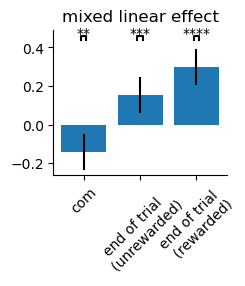

In [37]:
# 4. Create the bar graph using matplotlib

fig, axes = plt.subplots(1,1,figsize=(3, 3.5))
annotations = []

#### axis 0
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result1)
axes.bar(coef_names, coef_est, error_kw=dict(color='k'))
for coef_name in coef_names:
    axes.plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        annotations.append((coef_ind, coef_ind, np.round(pvalue, 4)))

starbars.draw_annotation(annotations, ax = axes)

axes.set_xticks(np.arange(len(coef_names)))
axes.set_xticklabels(coef_names, rotation=45)
axes.set_title("mixed linear effect")
axes.spines[['right', 'top']].set_visible(False)

fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

plt.savefig(f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure2/figure2_SWR_count_regression.pdf',dpi=300,bbox_inches='tight')

In [38]:
ExportSelection().stop_export(**paper_key, analysis_id="ripple")

[22:28:57][WARNING] Spyglass: Export not in progress.


## End

### 4. Plot content vs animal location

In [133]:
from spyglass.shijiegu.changeOfMind_figures.figure2_ripple import return_decode_pos_snippets
from spyglass.shijiegu.changeOfMind_triggered import plot_physical_vs_mental_position, form_null_model

In [148]:
def plot(position_pre, decode_pre, position_pre_control, decode_pre_control, title, ax):
    
    gaussian_process, X_train, Y_train = form_null_model(position_pre_control, decode_pre_control)
    
    X_query = np.linspace(0,100,100).reshape((-1,1))
    mean_prediction, std_prediction = gaussian_process.predict(X_query, return_std=True)
    
    plot_physical_vs_mental_position(title, position_pre, decode_pre, color_method = 'random', save_name = None, ax = ax)

    ax.scatter(mean_prediction, X_query, label="Mean prediction",zorder=101)
    ax.fill_betweenx(
        X_query.ravel(),
        mean_prediction - 3 * std_prediction,
        mean_prediction + 3 * std_prediction,
        alpha = 0.3,
        label = r"99% confidence interval",
        zorder = 102,
        color = 'teal',
    )

### load data

In [143]:
animal = "eliot"

In [163]:
# load control
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4'
file_path = f"{output_folder}/prepost.pickle"

with open(file_path, 'rb') as file:
    loaded_data = pickle.load(file)
    print(f"Data successfully loaded from {file_path}")
globals().update(loaded_data)

# load SWR data
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure2'
file_path = f"{output_folder}/{animal[:5]}_ripple.pickle"

with open(file_path, 'rb') as file:
    data = pickle.load(file)
    print(f"Data successfully loaded from {file_path}")

dates_to_plot = list(data["ranges"].keys())


Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure4/prepost.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/eliot_ripple.pickle


In [164]:
loaded_data.keys()

dict_keys(['position_data_pre', 'position_data_pre_control', 'decode_data_pre', 'decode_data_pre_control', 'time_data_pre', 'time_data_pre_control', 'position_data_post', 'position_data_post_control', 'decode_data_post', 'decode_data_post_control', 'time_data_post', 'time_data_post_control', 'dist_pre', 'dist_post', 'dist_pre_control', 'dist_post_control', 'position_infos'])

In [258]:
list(data["ranges"].keys())

['20221018',
 '20221019',
 '20221020',
 '20221021',
 '20221022',
 '20221023',
 '20221024',
 '20221025',
 '20221026']

In [327]:
animal = "lewis"

# load SWR data
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure2'
file_path = f"{output_folder}/{animal[:5]}_ripple.pickle"

with open(file_path, 'rb') as file:
    data = pickle.load(file)
    print(f"Data successfully loaded from {file_path}")

dates_to_plot = list(data["ranges"].keys())

positions1d_swr_all, positions2d_swr_all, decodes1d_swr_all, decodes2d_swr_all, info_swr_all, positions_infos_all  = [], [], [], [], [], []
for day in dates_to_plot:
    positions1d_swr, positions2d_swr, decodes1d_swr, decodes2d_swr, info_swr, positions_infos = return_decode_pos_snippets(animal,day,
                                                                                   data['ripple_ind_both'][day],
                                                                                   data['session_names_both'][day],
                                                                                  'default_conservative')
    positions1d_swr_all.extend(positions1d_swr)
    positions2d_swr_all.extend(positions2d_swr)
    decodes1d_swr_all.extend(decodes1d_swr)
    decodes2d_swr_all.extend(decodes2d_swr)
    info_swr_all.extend(info_swr)
    positions_infos_all.extend(positions_infos)

[13:59:26][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-01-11 13:59:26,353][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8c89b9b2c, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_V9VFCR92YP.nwb
[2026-01-11 13:59:26,362][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8c89b9b2c, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_V9VFCR92YP.nwb
[2026-01-11 13:59:26,370][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8c89b9b2c, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_V9VFCR92YP.nwb
[2026-01-11 13:59:26,376][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/lewis_ripple.pickle


[2026-01-11 13:59:27,700][WARNING]: Skipped checksum for file with hash: 12d551fb-a9c1-4baf-8ea2-c0fc6d8552c3, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_2KIVRI0X14.nwb
[2026-01-11 13:59:27,711][WARNING]: Skipped checksum for file with hash: 12d551fb-a9c1-4baf-8ea2-c0fc6d8552c3, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_2KIVRI0X14.nwb
[2026-01-11 13:59:27,722][WARNING]: Skipped checksum for file with hash: 12d551fb-a9c1-4baf-8ea2-c0fc6d8552c3, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_2KIVRI0X14.nwb
[2026-01-11 13:59:27,731][WARNING]: Skipped checksum for file with hash: 12d551fb-a9c1-4baf-8ea2-c0fc6d8552c3, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_2KIVRI0X14.nwb
[13:59:29][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spy

some missing position data


[13:59:34][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-01-11 13:59:34,536][WARNING]: Skipped checksum for file with hash: da474647-aada-1e90-1718-0310790b7330, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_OZ3XM382BB.nwb
[2026-01-11 13:59:34,546][WARNING]: Skipped checksum for file with hash: da474647-aada-1e90-1718-0310790b7330, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_OZ3XM382BB.nwb
[2026-01-11 13:59:34,555][WARNING]: Skipped checksum for file with hash: da474647-aada-1e90-1718-0310790b7330, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_OZ3XM382BB.nwb
[2026-01-11 13:59:34,561][WARNING]: Skipped checksum for file with hash: da474647-aada-1e90-1718-0310

...

[13:59:46][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-01-11 13:59:46,834][WARNING]: Skipped checksum for file with hash: cb88d188-922d-8c68-a7b6-80dbeb137ebe, and path: /stelmo/nwb/analysis/lewis20240108/lewis20240108_H7AS5OPWRH.nwb
[2026-01-11 13:59:46,841][WARNING]: Skipped checksum for file with hash: cb88d188-922d-8c68-a7b6-80dbeb137ebe, and path: /stelmo/nwb/analysis/lewis20240108/lewis20240108_H7AS5OPWRH.nwb
[2026-01-11 13:59:46,847][WARNING]: Skipped checksum for file with hash: cb88d188-922d-8c68-a7b6-80dbeb137ebe, and path: /stelmo/nwb/analysis/lewis20240108/lewis20240108_H7AS5OPWRH.nwb
[2026-01-11 13:59:46,854][WARNING]: Skipped checksum for file with hash: cb88d188-922d-8c68-a7b6-80db

some missing position data


[13:59:49][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-01-11 13:59:49,623][WARNING]: Skipped checksum for file with hash: 7ed35489-64ab-8ec4-df6d-8f7cf8f5abea, and path: /stelmo/nwb/analysis/lewis20240108/lewis20240108_VF6X4UMHFG.nwb
[2026-01-11 13:59:49,628][WARNING]: Skipped checksum for file with hash: 7ed35489-64ab-8ec4-df6d-8f7cf8f5abea, and path: /stelmo/nwb/analysis/lewis20240108/lewis20240108_VF6X4UMHFG.nwb
[2026-01-11 13:59:49,634][WARNING]: Skipped checksum for file with hash: 7ed35489-64ab-8ec4-df6d-8f7cf8f5abea, and path: /stelmo/nwb/analysis/lewis20240108/lewis20240108_VF6X4UMHFG.nwb
[2026-01-11 13:59:49,638][WARNING]: Skipped checksum for file with hash: 7ed35489-64ab-8ec4-df6d-8f7c

some missing position data


[14:00:06][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-01-11 14:00:06,243][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6be577699, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_6K2WVTTBUQ.nwb
[2026-01-11 14:00:06,251][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6be577699, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_6K2WVTTBUQ.nwb
[2026-01-11 14:00:06,259][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6be577699, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_6K2WVTTBUQ.nwb
[2026-01-11 14:00:06,264][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6

In [346]:
info_swr_all

[('lewis20240105_.nwb',
  '04_Rev2Session2',
  (1704485735.3959525, 1704485735.4459524)),
 ('lewis20240105_.nwb',
  '04_Rev2Session2',
  (1704486628.9436998, 1704486628.9757)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489776.3991823, 1704489776.4731824)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489854.995164, 1704489855.069164)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489859.145163, 1704489859.407163)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489860.1751628, 1704489860.2691627)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489860.2771628, 1704489860.3331628)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489861.4431624, 1704489861.5591624)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489861.7691624, 1704489862.0871623)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489863.299162, 1704489863.547162)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489923.369148, 1704489923.443148)),
 ('lewis20240105_.nwb

In [328]:
len(positions1d_swr_all)

40

In [329]:
len(positions2d_swr_all)

40

[14:03:04][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


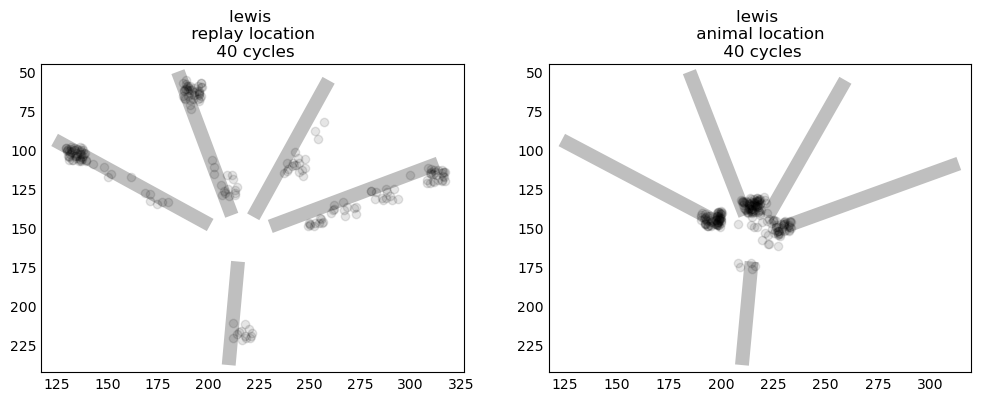

In [333]:
plot_density(animal, decodes2d_swr_all, positions2d_swr_all, use_all = True)

In [357]:
log_df

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,change_of_mind,CoMMaxProportion,initial_choice,initial_time,proportion_arm1,...,proportion_arm3,proportion_arm4,CoMNum_by_time,CoMNum_by_arm,CoM_arm,current,future_H,future_O,past,past_reward
1,1.650308e+09,1.0,1.650308e+09,4.0,1.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],4.0,4.0,2.0,NaN,NaN
2,1.650308e+09,1.0,1.650308e+09,2.0,1.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],2.0,2.0,3.0,4.0,NaN
3,1.650308e+09,1.0,1.650308e+09,3.0,2.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],3.0,3.0,1.0,2.0,NaN
4,1.650308e+09,1.0,1.650308e+09,1.0,1.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],1.0,1.0,4.0,3.0,3.0
5,1.650308e+09,1.0,1.650308e+09,4.0,2.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],4.0,4.0,2.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,1.650310e+09,1.0,1.650310e+09,1.0,2.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],1.0,1.0,4.0,2.0,2.0
79,1.650310e+09,1.0,1.650310e+09,4.0,1.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],4.0,4.0,3.0,1.0,1.0
80,1.650310e+09,1.0,1.650310e+09,3.0,2.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],3.0,3.0,2.0,4.0,1.0
81,1.650310e+09,1.0,1.650310e+09,2.0,2.0,False,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,[],2.0,2.0,NaN,3.0,3.0


In [351]:
diff = []
for pos,dec in zip(positions_swr_all, decodes_swr_all):
    diff.append(np.mean(np.abs(pos - dec)))

In [352]:
diff

[137.62127898946218,
 5.183376046080581,
 307.7027862881684,
 2.2153922587706636,
 3.4907684246416264,
 329.6940329233352,
 0.8621906893892057,
 79.1434406120943,
 0.49863107965671866,
 3.110829990557322,
 1.7041074117694932,
 0.7525705968349905,
 351.51549482023097,
 368.26567300456014,
 110.29605109351962,
 246.6766856247829,
 0.9243679980127093,
 2.4854989123977833,
 34.913506260534355,
 61.54465422350313,
 3.319010662976284,
 13.356789095946917,
 294.4346360139501,
 2.319076673812654]

In [287]:
from spyglass.shijiegu.changeOfMind_triggered import region

In [288]:
region

{5: array([ 0.        , 57.63896252]),
 6: array([165.66041604, 252.64353221]),
 7: array([331.10211383, 418.29227956]),
 8: array([496.49241045, 583.18763812]),
 9: array([657.72023142, 743.03215907])}

In [347]:
info_swr_all

[16:11:18][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[16:11:18][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


[('lewis20240105_.nwb',
  '04_Rev2Session2',
  (1704485735.3959525, 1704485735.4459524)),
 ('lewis20240105_.nwb',
  '04_Rev2Session2',
  (1704486628.9436998, 1704486628.9757)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489776.3991823, 1704489776.4731824)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489854.995164, 1704489855.069164)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489859.145163, 1704489859.407163)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489860.1751628, 1704489860.2691627)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489860.2771628, 1704489860.3331628)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489861.4431624, 1704489861.5591624)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489861.7691624, 1704489862.0871623)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489863.299162, 1704489863.547162)),
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  (1704489923.369148, 1704489923.443148)),
 ('lewis20240105_.nwb

In [353]:
info_swr_all[0]

('lewis20240105_.nwb',
 '04_Rev2Session2',
 (1704485735.3959525, 1704485735.4459524))

In [354]:
positions_swr_all[0]

array([85.22915063, 85.22669094, 85.22954002, 85.23484879, 85.24015755,
       85.24546632, 85.25077509, 85.25608386, 85.26139263, 85.2667014 ,
       85.27201017, 85.27731894, 85.28262771, 85.28793648, 85.29324524,
       85.29855401, 85.30386278, 85.30917155, 85.31448032, 85.31978909,
       85.32509786, 85.33040663, 85.3357154 , 85.34102417, 85.35188301,
       85.35743309, 85.36298317, 85.36853324, 85.37408332, 85.3796334 ,
       85.38518347, 85.39073355, 85.39628363, 85.4018337 , 85.40738378,
       85.41293386, 85.41848393, 85.42403401, 85.42958409, 85.43513416,
       85.44068424, 85.44623432, 85.45178439, 85.45733447, 85.46288455,
       85.47411084, 85.47978705, 85.48546327, 85.49113948, 85.4968157 ,
       85.50249191, 85.50816813, 85.51384434, 85.51952056, 85.52519677,
       85.53087299, 85.5365492 , 85.54222542, 85.54790163, 85.55357784,
       85.55925406, 85.56493027, 85.57060649, 85.5762827 , 85.58195892,
       85.58763513, 85.60392889, 85.61454642, 85.62516396, 85.63

In [355]:
decodes_swr_all[0]

array([ 76.5178749 ,  62.60709735,  64.59435129,  66.58160522,
        68.56885916,  66.58160522,  68.56885916,  82.4796367 ,
        84.46689063,  86.45414457,  78.50512883,  82.4796367 ,
        80.49238276,  78.50512883, 629.90230904,  76.5178749 ,
        86.45414457,  86.45414457,  88.4413985 ,  88.4413985 ,
        86.45414457,  82.4796367 ,  88.4413985 ,  90.42865244,
        88.4413985 ,  88.4413985 ,  88.4413985 , 401.44872482,
       401.44872482, 401.44872482, 403.43031949, 395.50394079,
       393.52234612, 391.54075144, 391.54075144, 389.55915676,
        86.45414457, 692.44020197, 700.37619524, 700.37619524,
       698.39219693, 698.39219693, 726.16817337,  84.46689063,
        84.46689063,  84.46689063,  84.46689063,  86.45414457,
        86.45414457,  86.45414457,  88.4413985 ,  88.4413985 ,
        88.4413985 ,  88.4413985 ,  86.45414457,  86.45414457,
        86.45414457,  84.46689063,  86.45414457,  88.4413985 ,
        88.4413985 ,  88.4413985 ,  88.4413985 ,  86.45

In [301]:
ind = 7
log_df = pd.DataFrame((ChangeofMind() & {"nwb_file_name": info_swr_all[ind][0],
                  "epoch":4, "proportion":0.1}).fetch1("pandas"))
log_df[log_df.change_of_mind].index[np.argwhere(log_df[log_df.change_of_mind].timestamp_H <= info_swr_all[ind][2][0])[-1]]

Index([32], dtype='int64')

In [302]:
log_df.loc[32]

timestamp_H                      1650308392.187298
Home                                           1.0
timestamp_O                      1650308409.597363
OuterWellIndex                                 4.0
rewardNum                                      1.0
change_of_mind                                True
CoMMaxProportion                          0.137601
initial_choice                                 1.0
initial_time                     1650308405.514469
proportion_arm1                           0.137601
proportion_arm2                                0.0
proportion_arm3                                0.0
proportion_arm4                                0.0
CoMNum_by_time                                   1
CoMNum_by_arm                                    1
CoM_arm             [[1, 4, -9223372036854775808]]
current                                        4.0
future_H                                       4.0
future_O                                       1.0
past                           

In [271]:
diff

[137.62127898946218,
 137.62127898946218,
 137.62127898946218,
 2.2153922587706636,
 2.2153922587706636,
 2.2153922587706636,
 0.8621906893892057,
 0.8621906893892057,
 0.49863107965671866,
 0.49863107965671866,
 0.49863107965671866,
 0.7525705968349905,
 351.51549482023097,
 351.51549482023097,
 351.51549482023097,
 351.51549482023097,
 0.9243679980127093,
 0.9243679980127093,
 0.9243679980127093,
 61.54465422350313,
 61.54465422350313,
 13.356789095946917,
 13.356789095946917,
 2.319076673812654]

<Axes: title={'center': 'molly'}, xlabel='decoded linearized loc (cm)', ylabel='linearized location (cm)'>

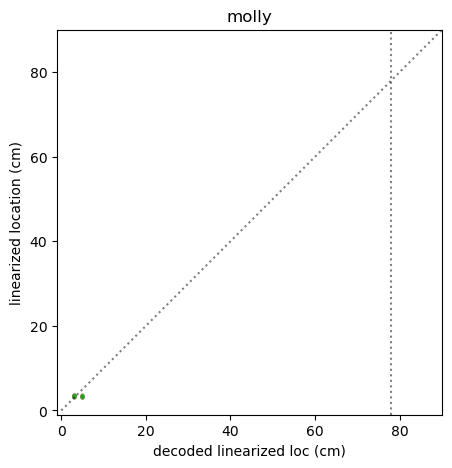

In [263]:
plot_physical_vs_mental_position(f"molly", positions_swr_all, decodes_swr_all, color_method = 'random', save_name = None)

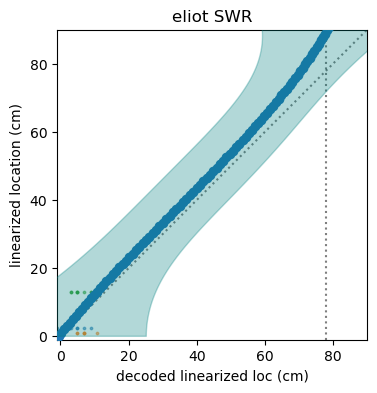

In [261]:
# plot
day = "20221021"
position_pre_control, position_post_control = position_data_pre_control[animal], position_data_post_control[animal]
decode_pre_control, decode_post_control = decode_data_pre_control[animal], decode_data_post_control[animal]

fig, axes = plt.subplots(1,1,figsize=(4,5))

plot(positions_swr_all, decodes_swr_all, position_pre_control, decode_pre_control, f"{animal} SWR", axes)

<Axes: title={'center': '5'}, xlabel='decoded linearized loc (cm)', ylabel='linearized location (cm)'>

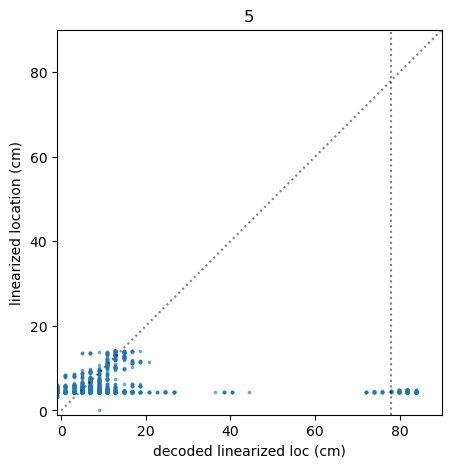

In [197]:
ind = 5
plot_physical_vs_mental_position(f"{ind}", [positions_swr[ind]], [decodes_swr[ind]], color_method = 'random', save_name = None)

<Axes: title={'center': '0'}, xlabel='decoded linearized loc (cm)', ylabel='linearized location (cm)'>

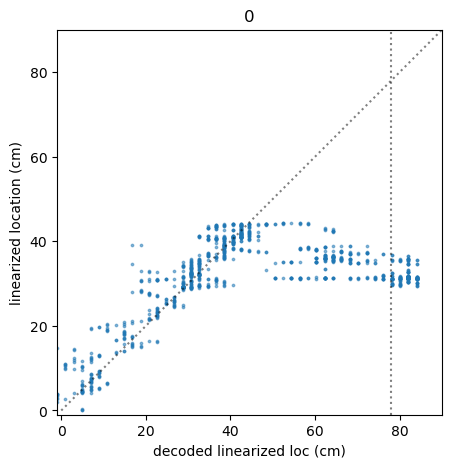

In [198]:
ind = 0
plot_physical_vs_mental_position(f"{ind}", [positions_swr[ind]], [decodes_swr[ind]], color_method = 'random', save_name = None)

In [203]:
info_swr[0]

('eliot20221021_.nwb',
 '04_Seq2Session2',
 1,
 (1666389669.9803505, 1666389672.5743492))

In [209]:
log_df = pd.DataFrame((ChangeofMind() & {"nwb_file_name": "eliot20221021_.nwb",
                  "epoch":4, "proportion":0.1}).fetch1("pandas"))
log_df[log_df.change_of_mind].index[np.argwhere(log_df[log_df.change_of_mind].timestamp_H <= 1666389669.9803505)[-1]]

Index([29], dtype='int64')

In [221]:
log_df[log_df.change_of_mind].loc[29].timestamp_H

1666389658.5996242

In [219]:
log_df[log_df.change_of_mind].loc[29].timestamp_O

1666389686.435649

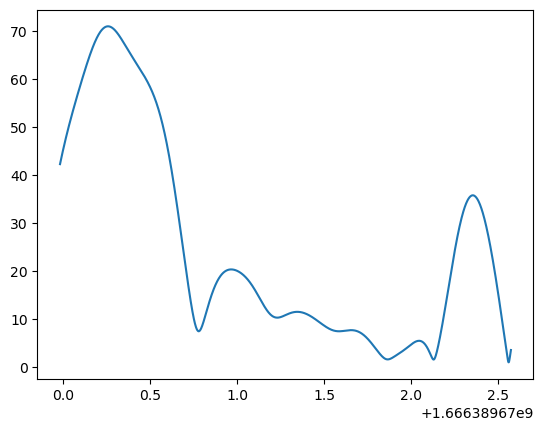

In [228]:
plt.plot(positions_infos[0].head_speed)

In [234]:
RippleTimesByParameters()

[autoreload of spyglass.shijiegu.changeOfMind_figures.figure2_ripple failed: Traceback (most recent call last):
  File "/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
  File "/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 619, in _exec
  File "<frozen importlib._bootstrap_external>", line 879, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1017, in get_code
  File "<frozen importlib._bootstrap_external>", line 947, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/home/shijiegu/Documents/spyglass/src/s

NameError: name 'RippleTimesByParameters' is not defined